In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


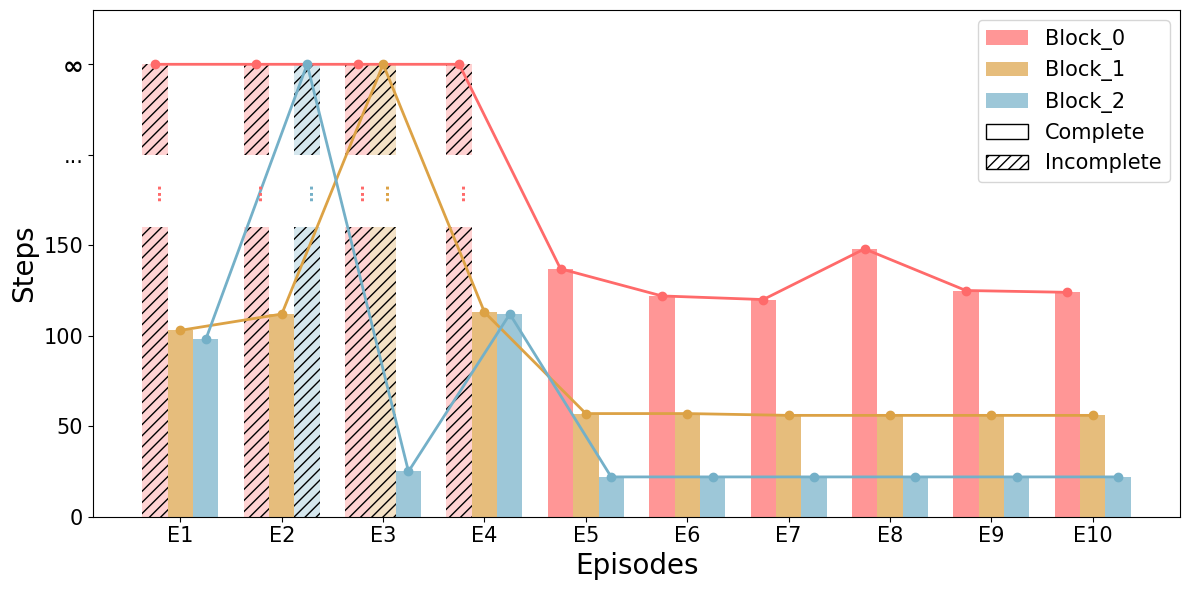

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Config ---
FILE_PATH = "block_completion_envsteps_fixed_ours.xlsx"  # change if needed
BLOCK_COLUMNS = ["Block_0", "Block_1", "Block_2"]
block_colors = [

    "#FF6A6A",
    "#DCA245",  # Block_0 → yellow
    "#74B0C8",  # Block_1 → light blue
]
bar_width = 0.25

# Broken-bar settings for ∞ values
fixed_bottom_h = 160    # lower segment height for infinite bars
gap_h = 40              # size of the visual gap between segments
inf_hatch = "///"       # hatch pattern for infinite bars
inf_alpha = 0.3         # transparency for infinite bars
finite_alpha = 0.7     # transparency for finite bars

# --- Load & prep data ---
df = pd.read_excel(FILE_PATH)
df = df.copy()
df.replace("inf", np.inf, inplace=True)  # normalize "inf" strings

for c in BLOCK_COLUMNS:
    df[c] = df[c].astype(float)

episodes = df["episode"].tolist()

# Max finite value across all blocks/rows
max_finite = df.replace(np.inf, np.nan)[BLOCK_COLUMNS].max().max()

# Axis top: ensure headroom; we'll place the ∞ tick slightly below it
axis_top = 280#max(max_finite * 2.0, fixed_bottom_h + gap_h + 80)
infinity_margin = max(0.05 * axis_top, 30)      # space above ∞
infinity_level = axis_top - infinity_margin     # where the "∞" tick will sit

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(episodes))

for i, col in enumerate(BLOCK_COLUMNS):
    values = df[col].values
    xpos = x + i * bar_width

    # Bars (finite and ∞-broken)
    for j, val in enumerate(values):
        if np.isfinite(val):
            # Finite (completed): solid, no hatch
            ax.bar(
                xpos[j], val, width=bar_width,
                color=block_colors[i], alpha=finite_alpha
            )
        else:
            # Infinite (incompleted): broken bar with hatch, same color
            # Bottom segment (fixed height)
            ax.bar(
                xpos[j], fixed_bottom_h, width=bar_width,
                color=block_colors[i], hatch=inf_hatch, alpha=inf_alpha
            )
            # Top segment: up to the infinity_level (not the top of the chart)
            top_segment_h = max(infinity_level - (fixed_bottom_h + gap_h), 0)
            ax.bar(
                xpos[j], top_segment_h, width=bar_width, bottom=fixed_bottom_h + gap_h,
                color=block_colors[i], hatch=inf_hatch, alpha=inf_alpha
            )
            # "..." centered in the gap (vertical orientation to suggest a break)
            ax.text(
                xpos[j], fixed_bottom_h + gap_h/2, "...",
                ha="center", va="center", fontsize=12, fontweight="bold",
                color=block_colors[i], rotation=90
            )

    # === Line plot overlay for this block ===
    # Use infinity_level for ∞ points so the line reaches the ∞ level
    y_vals = [v if np.isfinite(v) else infinity_level for v in values]
    ax.plot(
        xpos, y_vals, marker="o", color=block_colors[i],
        linestyle="-", linewidth=2
    )

# Axes & labels
ax.set_xticks(x + bar_width)
ax.set_xticklabels(episodes, fontsize=15)
ax.set_ylabel("Steps", fontsize=20)
ax.set_xlabel("Episodes", fontsize=20)
# Y-axis: ∞ placed slightly below top; 200/250 labeled as "..."
ax.set_ylim(0, axis_top)
ticks = [t for t in ax.get_yticks() if t < axis_top * 0.9]
# Force inclusion of the ∞ level as a tick
if infinity_level not in ticks:
    ticks.append(infinity_level)
# Sort ticks (in case the append changed order)
ticks = sorted(ticks)
ax.set_yticks(ticks)

def _fmt_tick(t):
    ti = int(round(t))
    # if ti in (200, 250):              # Replace 200/250 with "..." --- IGNORE ---
    if ti == 200:
        return "..."
    if abs(t - infinity_level) < 1e-6:
        return "∞"
    return str(ti)

tick_labels = [_fmt_tick(t) for t in ticks]
ax.set_yticklabels(tick_labels, fontsize=15)

# Make the ∞ tick bigger & bold
for label, tick in zip(ax.get_yticklabels(), ticks):
    if abs(tick - infinity_level) < 1e-6:
        label.set_fontsize(18)
        label.set_fontweight("bold")

# Legend:
# - One entry per Block (color only, no hatch)
# - Two style entries: completed (unhatched), incompleted (hatched)
block_handles = [
    Patch(facecolor=block_colors[i], label=f"Block_{i}", alpha=finite_alpha)
    for i in range(len(BLOCK_COLUMNS))
]
status_handles = [
    Patch(facecolor="white", edgecolor="black", label="Complete"),
    Patch(facecolor="white", edgecolor="black", hatch=inf_hatch, label="Incomplete")
]
ax.legend(handles=block_handles + status_handles, loc="upper right", fontsize=15)

# No title
plt.tight_layout()
plt.show()


In [17]:
import pandas as pd
import numpy as np
def convert_csv_to_wide_format(file_path):
    df = pd.read_csv("block_completion_timing_ours.csv")

    # Use completion time for all blocks (rounded to int)
    df["value"] = df["completion_time_seconds"].apply(lambda x: int(round(float(x))))

    # Add labels
    df["episode"] = "E" + df["episode_num"].astype(int).astype(str)
    df["block"] = "Block_" + df["block_id"].astype(int).astype(str)

    # Pivot into wide table
    wide = df.pivot_table(index="episode", columns="block", values="value", aggfunc="first")

    # Reorder rows and columns
    episodes = [f"E{i}" for i in sorted(df["episode_num"].unique())]
    cols = [f"Block_{i}" for i in [0,1,2]]
    wide = wide.reindex(index=episodes, columns=cols)

    # Replace missing values with 'inf'
    wide = wide.where(~wide.isna(), other="inf")

    # Ensure all values are strings (to match "inf" style)
    for c in wide.columns:
        wide[c] = wide[c].apply(lambda x: str(int(x)) if isinstance(x, (int, float, np.integer, np.floating)) and x == x else x)

    # Reset index so "episode" is a column
    wide.reset_index(inplace=True)
    return wide

In [19]:
df

block,episode,Block_0,Block_1,Block_2
0,E1,inf,25.0,22.0
1,E2,inf,22.0,22.0
2,E3,inf,inf,8.0
3,E4,inf,29.0,29.0
4,E5,40.0,19.0,8.0
5,E6,51.0,17.0,8.0
6,E7,50.0,16.0,7.0
7,E8,37.0,16.0,7.0
8,E9,52.0,18.0,9.0
9,E10,49.0,17.0,8.0


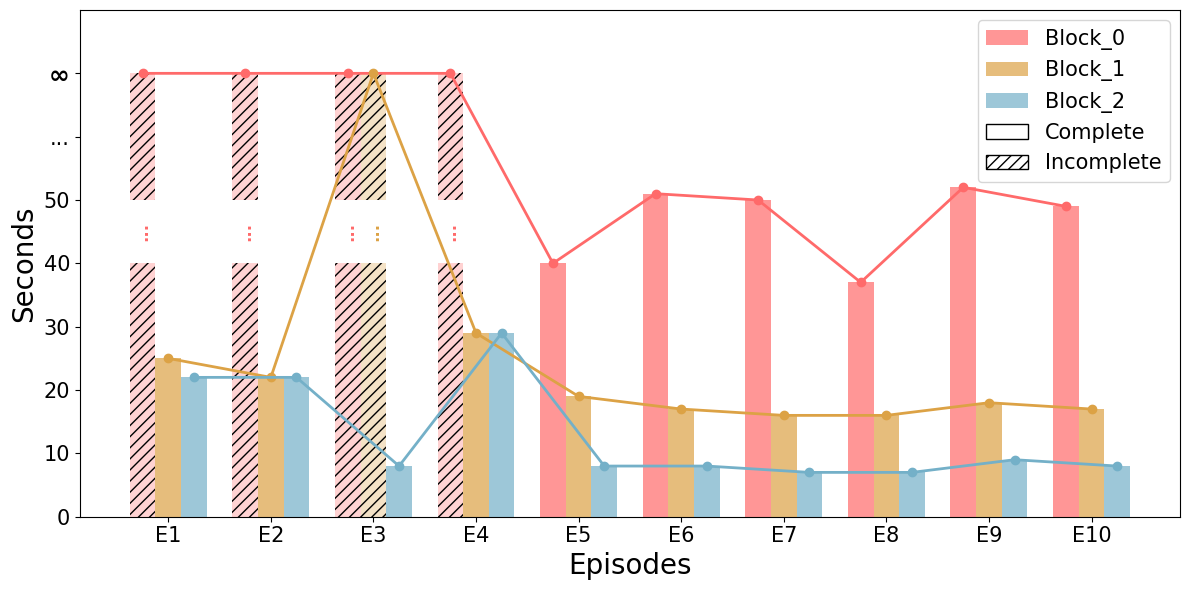

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Config ---
FILE_PATH = "block_completion_timing_ours.csv"  # change if needed
BLOCK_COLUMNS = ["Block_0", "Block_1", "Block_2"]
block_colors = [

    "#FF6A6A",
    "#DCA245",  # Block_0 → yellow
    "#74B0C8",  # Block_1 → light blue
]
bar_width = 0.25

# Broken-bar settings for ∞ values
fixed_bottom_h = 40    # lower segment height for infinite bars
gap_h = 10              # size of the visual gap between segments
inf_hatch = "///"       # hatch pattern for infinite bars
inf_alpha = 0.3         # transparency for infinite bars
finite_alpha = 0.7     # transparency for finite bars

# --- Load & prep data ---
df = convert_csv_to_wide_format(FILE_PATH)
df = df.copy()
df.replace("inf", np.inf, inplace=True)  # normalize "inf" strings

for c in BLOCK_COLUMNS:
    df[c] = df[c].astype(float)

episodes = df["episode"].tolist()

# Max finite value across all blocks/rows
max_finite = df.replace(np.inf, np.nan)[BLOCK_COLUMNS].max().max()

# Axis top: ensure headroom; we'll place the ∞ tick slightly below it
axis_top = 80#max(max_finite * 2.0, fixed_bottom_h + gap_h + 80)
infinity_margin = max(0.01 * axis_top, 10)      # space above ∞
infinity_level = axis_top - infinity_margin     # where the "∞" tick will sit

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(episodes))

for i, col in enumerate(BLOCK_COLUMNS):
    values = df[col].values
    xpos = x + i * bar_width

    # Bars (finite and ∞-broken)
    for j, val in enumerate(values):
        if np.isfinite(val):
            # Finite (completed): solid, no hatch
            ax.bar(
                xpos[j], val, width=bar_width,
                color=block_colors[i], alpha=finite_alpha
            )
        else:
            # Infinite (incompleted): broken bar with hatch, same color
            # Bottom segment (fixed height)
            ax.bar(
                xpos[j], fixed_bottom_h, width=bar_width,
                color=block_colors[i], hatch=inf_hatch, alpha=inf_alpha
            )
            # Top segment: up to the infinity_level (not the top of the chart)
            top_segment_h = max(infinity_level - (fixed_bottom_h + gap_h), 0)
            ax.bar(
                xpos[j], top_segment_h, width=bar_width, bottom=fixed_bottom_h + gap_h,
                color=block_colors[i], hatch=inf_hatch, alpha=inf_alpha
            )
            # "..." centered in the gap (vertical orientation to suggest a break)
            ax.text(
                xpos[j], fixed_bottom_h + gap_h/2, "...",
                ha="center", va="center", fontsize=12, fontweight="bold",
                color=block_colors[i], rotation=90
            )

    # === Line plot overlay for this block ===
    # Use infinity_level for ∞ points so the line reaches the ∞ level
    y_vals = [v if np.isfinite(v) else infinity_level for v in values]
    ax.plot(
        xpos, y_vals, marker="o", color=block_colors[i],
        linestyle="-", linewidth=2
    )

# Axes & labels
ax.set_xticks(x + bar_width)
ax.set_xticklabels(episodes, fontsize=15)
ax.set_ylabel("Seconds", fontsize=20)
ax.set_xlabel("Episodes", fontsize=20)
# Y-axis: ∞ placed slightly below top; 200/250 labeled as "..."
ax.set_ylim(0, axis_top)
ticks = [t for t in ax.get_yticks() if t < axis_top * 0.9]
# Force inclusion of the ∞ level as a tick
if infinity_level not in ticks:
    ticks.append(infinity_level)
# Sort ticks (in case the append changed order)
ticks = sorted(ticks)
ax.set_yticks(ticks)

def _fmt_tick(t):
    ti = int(round(t))
    # if ti in (200, 250):              # Replace 200/250 with "..." --- IGNORE ---
    if ti == 60:
        return "..."
    if abs(t - infinity_level) < 1e-6:
        return "∞"
    return str(ti)

tick_labels = [_fmt_tick(t) for t in ticks]
ax.set_yticklabels(tick_labels, fontsize=15)

# Make the ∞ tick bigger & bold
for label, tick in zip(ax.get_yticklabels(), ticks):
    if abs(tick - infinity_level) < 1e-6:
        label.set_fontsize(18)
        label.set_fontweight("bold")

# Legend:
# - One entry per Block (color only, no hatch)
# - Two style entries: completed (unhatched), incompleted (hatched)
block_handles = [
    Patch(facecolor=block_colors[i], label=f"Block_{i}", alpha=finite_alpha)
    for i in range(len(BLOCK_COLUMNS))
]
status_handles = [
    Patch(facecolor="white", edgecolor="black", label="Complete"),
    Patch(facecolor="white", edgecolor="black", hatch=inf_hatch, label="Incomplete")
]
ax.legend(handles=block_handles + status_handles, loc="upper right", fontsize=15)

# No title
plt.tight_layout()
plt.show()
